In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

In [2]:
# len in meters
l = 0.02
b = 5e-3
d = 200e-6

g_a = 100e-6
g_d = 100e-6

# N / m**2
E = 98e9
# kg / m**3
rho = 8.5e3
v_upsilon = np.sqrt(E / rho)

# C_a = epsilon_0 * S / g_a

# m = rho * l * b * d

# F_0_theo = 1/2 * C_a * U**2 / g_a

ALPHA_N = [1.424987, 0.992249, 1.000198, 0.999994]

def get_alpha_n(n: int):
    if n > 3:
        return 1
    return ALPHA_N[n]

def calc_free_reed_eigenfrequency(n: int):
    alpha_n = get_alpha_n(n)
    nu = alpha_n * (2 * n + 1)**2 * np.pi * d * v_upsilon / (16 * np.sqrt(3) * l**2)
    return nu

target_freqs = [calc_free_reed_eigenfrequency(n) for n in range(4)]
print(target_freqs)
for i, freq in enumerate(target_freqs[1:]):
    print(f"nu_{i+1}/nu_0 = {freq / target_freqs[0]}")

target_freqs = target_freqs[:3]
lowest_harmonic = target_freqs[0]

[np.float64(274.25448868690813), np.float64(1718.723524709954), np.float64(4812.478834467755), np.float64(9430.53467494007)]
nu_1/nu_0 = 6.266892961128769
nu_2/nu_0 = 17.547493415729406
nu_3/nu_0 = 34.38607229399286


In [3]:
LORENTZ_FIT_PARAM_NAMES = ('f_0', 'omega_0', 'gamma')

def lorentz_curve(f, f_0, omega_0, gamma):
    omega = 2 * np.pi * f
    return f_0 / np.sqrt((omega_0**2 - omega**2)**2 + gamma**2 * omega**2)

def phase_func(f, omega_0, gamma):
    omega = 2 * np.pi * f
    return np.arctan(gamma * omega / (omega_0**2 - omega**2))

def calc_Q_factor(params, params_err):
    omega_0 = params[1]
    gamma = params[2]
    omega_0_err = params_err[1]
    gamma_err = params_err[2]
    Q = omega_0 / gamma
    Q_err = Q * np.sqrt((omega_0 / omega_0_err)**2 + (gamma_err / gamma)**2)
    return Q, Q_err

In [4]:
import ast

def fit_analysis_lorentz(ax, freq, A, A_err, p0):
    params, pcov = curve_fit(
        lorentz_curve,
        freq,
        A,
        p0=p0,
        sigma=A_err,
        absolute_sigma=True
    )
    params_err = np.sqrt(np.diag(pcov))

    xgrid = np.linspace(np.min(freq), np.max(freq), 300)
    ax.plot(xgrid, lorentz_curve(xgrid, *params), label="Fit Curve")
    
    return params, params_err

def read_metadata(loc):
    with open(loc, "r") as file:
        return ast.literal_eval(file.readline())

def plot_target_freq(ax, target_freq: float, target_freq_name, height=10):
    axes = ax.axis()
    ax.vlines(target_freq, -height, height, colors="tab:grey", linestyles="--", label=target_freq_name)
    ax.axis(axes)

def read_exp_file(loc):
    freq, A, A_err, phi, phi_err = np.loadtxt(
        loc,
        delimiter=",",
        skiprows=2,
        unpack=True
    )
    metadata = read_metadata(loc)
    return (freq, A, A_err, phi, phi_err), metadata

def plot_freq_spectrum(fig, axs, data):
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    X = A * np.cos(phi)
    Y = A * np.sin(phi)

    ax1, ax2, ax3 = axs[0], axs[1], axs[2]
    ax1.errorbar(freq, A, yerr=A_err)
    ax1.set_xlabel(r"$\nu$ / Hz")
    ax1.set_ylabel(r"$A$ / Vpp")
    ax1.set_title("Resonance Curve (Amplitude)")
    
    ax2.errorbar(freq, phi, yerr=phi_err)
    ax2.set_xlabel(r"$\nu$ / Hz")
    ax2.set_ylabel(r"$\phi$")
    ax2.set_title("Phase Shift")

    ax3.errorbar(freq, X, label="$X = A \\cos (\\phi)$")
    ax3.errorbar(freq, Y, label="$Y = A \\sin (\\phi)$")
    ax3.set_xlabel(r"$\nu$ / Hz")
    ax3.set_ylabel(r"Amplitude / Vpp")
    ax3.set_title("Waveform Chart")
    ax3.legend()

    return fig, axs


Success at finding fit parameters for target frequency 125.00 Hz.
f_0     = 0.269868152336441 ± 0.0003910472765672221
omega_0 = 785.7352920777228 ± 0.003953801442939989
gamma   = -5.06297584087183 ± 0.00921451986082475
Resulting Q-factor: -155.19238423670245 ± -30841238.518490363


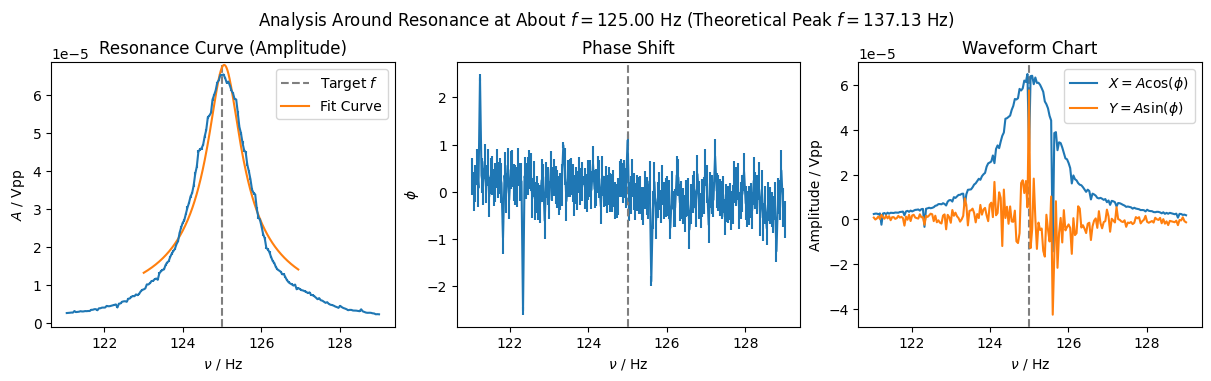

Success at finding fit parameters for target frequency 825.00 Hz.
f_0     = 0.09776990178262471 ± 0.0009142744002784709
omega_0 = 5183.7500679215855 ± 0.06565447366794695
gamma   = -8.46063775954522 ± 0.1277887655494736
Resulting Q-factor: -612.6902268181051 ± -48374967.11871238


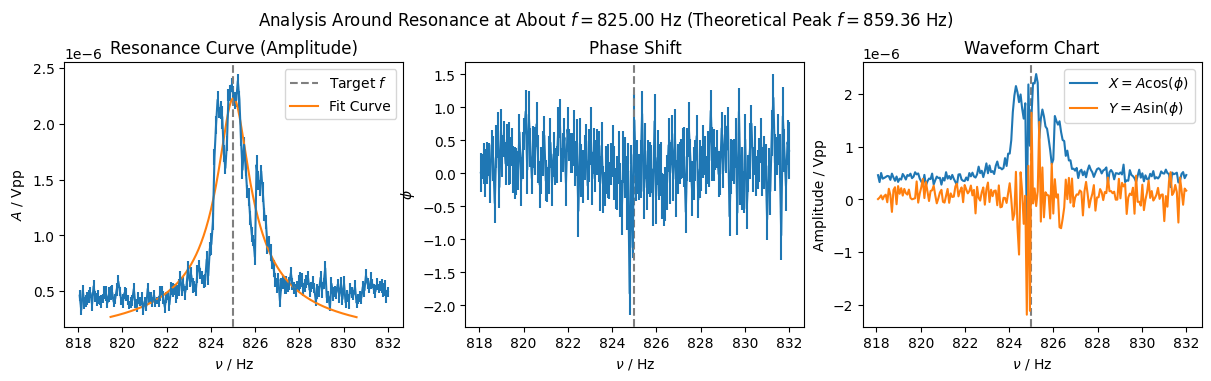

Success at finding fit parameters for target frequency 2406.24 Hz.
f_0     = 43.29793571532871 ± 58.949222395240184
omega_0 = 18.411305382496565 ± 12705609.168347297
gamma   = 21.513387810627354 ± 15068959.613765946
Resulting Q-factor: 0.8558068838140687 ± 599446.2370546102


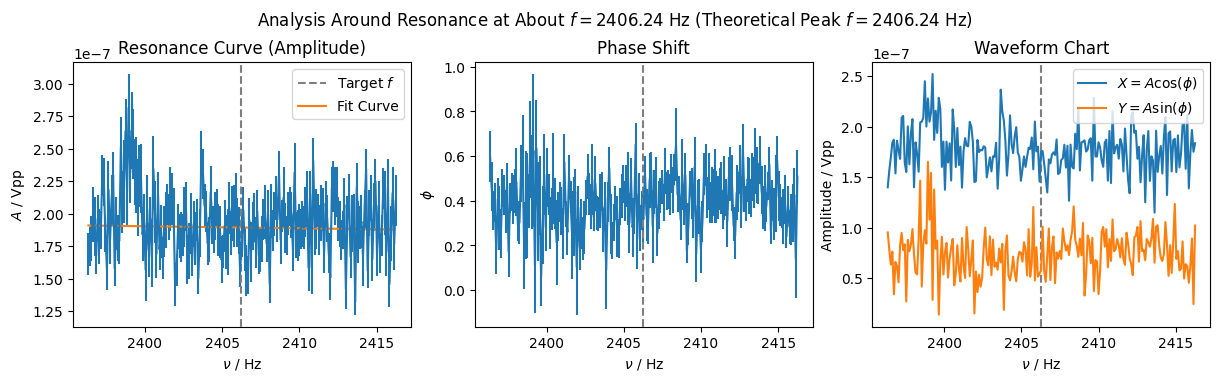

In [5]:
locs = [
    "./Data/Final/Experiment_A/resonance0_data_0709_175609.txt",
    "./Data/Final/Experiment_A/resonance1_data_0709_190116.txt",
    "./Data/Final/Experiment_A/resonance2_data_0709_200623.txt"
]
p0s = [
    (0.002, 1, 1),
    (0.002, 1, 1),
    (0.002, 1, 1),
]
fit_limss = [
    (50, -50),
    (20, -20),
    (0, -1),
]

expA_fitparam_results: list[dict] = [{}] * len(locs)

for i, (loc, p0, fit_lims) in enumerate(zip(locs, p0s, fit_limss)):
    data, metadata = read_exp_file(loc)
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    target_freq = metadata["target_freq"]
    theo_target_freq = metadata["theoretical_target_freq"]

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plot_freq_spectrum(fig, axs, data)
    for ax in axs:
        plot_target_freq(ax, target_freq, 'Target $ f $')

    result_dict = {'target_freq': target_freq, 'theo_target_freq': theo_target_freq}
    try:
        params, params_err = fit_analysis_lorentz(
            axs[0],
            freq[fit_lims[0]:fit_lims[1]],
            A[fit_lims[0]:fit_lims[1]],
            A_err[fit_lims[0]:fit_lims[1]],
            p0
        )
        print(f"Success at finding fit parameters for target frequency {target_freq:.2f} Hz.")
        for param_name, param, param_err in zip(LORENTZ_FIT_PARAM_NAMES, params, params_err):
            result_dict[param_name] = param
            result_dict[param_name + '_err'] = param_err
            print(f'{param_name:<7} = {param} ± {param_err}')
        Q, Q_err = calc_Q_factor(params, params_err)
        result_dict['Q'] = Q
        result_dict['Q_err'] = Q_err
        print(f'Resulting Q-factor: {Q} ± {Q_err}')
        result_dict['params_list'] = params
        result_dict['params_err_list'] = params_err
    except RuntimeError as r_e:
        print(f"Finding fit parameters was not possible for target frequency {target_freq:.2f} Hz.")

    expA_fitparam_results[i] = result_dict

    axs[0].legend()
    fig.suptitle(f"Analysis Around Resonance at About $ f = {target_freq:.2f}$ Hz (Theoretical Peak $ f = {theo_target_freq:.2f} $ Hz)")
    plt.show()

Target Frequency: 125 Hz
dof: 196
chi2_val: 28663.87505960452
red_chi2_val: 146.24426050818633
p-Value: 0.0


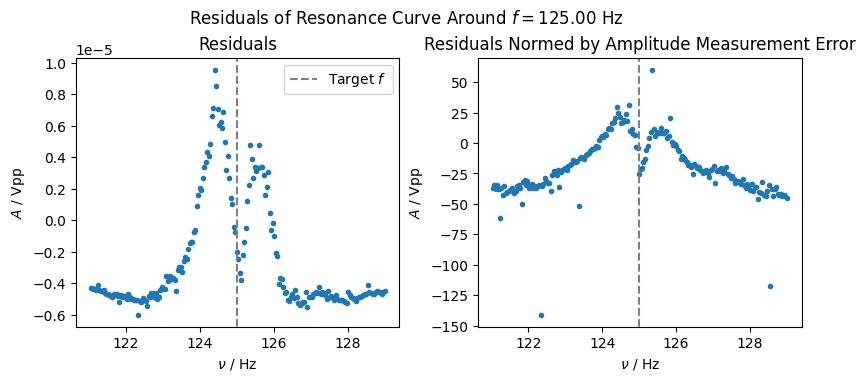

Target Frequency: 825 Hz
dof: 196
chi2_val: 1740.2165878095689
red_chi2_val: 8.878656060252903
p-Value: 2.106204480879714e-245


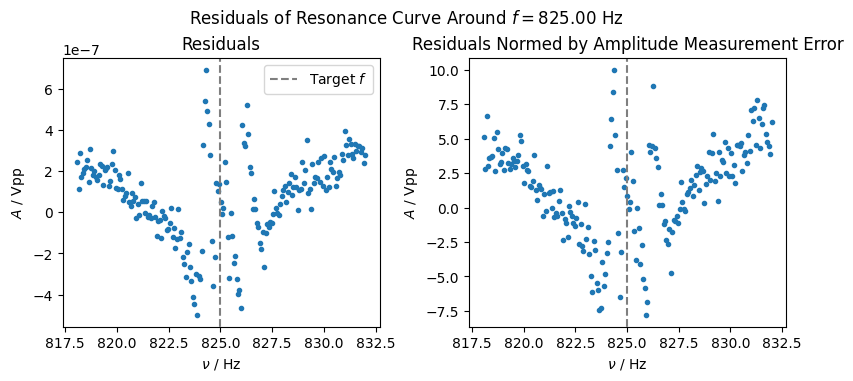

Target Frequency: 2406.2394172338777 Hz
dof: 196
chi2_val: 353.520297505327
red_chi2_val: 1.8036749872720765
p-Value: 3.8595497736493086e-11


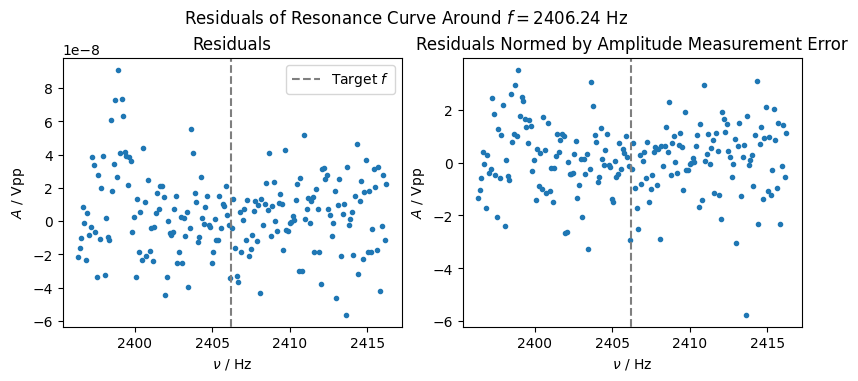

In [6]:
from scipy.stats import chi2

for i, (loc, fit_lims) in enumerate(zip(locs, fit_limss)):
    data, metadata = read_exp_file(loc)
    (freq, A, A_err, phi, phi_err) = data
    freq, A, A_err, phi, phi_err = freq[1:], A[1:], A_err[1:], phi[1:], phi_err[1:]
    target_freq = metadata["target_freq"]
    # theo_target_freq = metadata["theoretical_target_freq"]

    params = expA_fitparam_results[i]['params_list']
    params_err = expA_fitparam_results[i]['params_err_list']

    fig, axs = plt.subplots(1, 2, figsize=(4*2, 3.7), constrained_layout=True)
    residuals = A - lorentz_curve(freq, *params)

    axs[0].scatter(freq, residuals, marker='.')
    plot_target_freq(axs[0], target_freq, 'Target $ f $', height=200)
    axs[0].legend()
    axs[0].set_xlabel(r"$\nu$ / Hz")
    axs[0].set_ylabel(r"$A$ / Vpp")
    axs[0].set_title(f"Residuals")

    axs[1].scatter(freq, residuals / A_err, marker='.')
    plot_target_freq(axs[1], target_freq, 'Target $ f $', height=200)
    axs[1].set_xlabel(r"$\nu$ / Hz")
    axs[1].set_ylabel(r"$A$ / Vpp")
    axs[1].set_title(f"Residuals Normed by Amplitude Measurement Error")

    fig.suptitle(f"Residuals of Resonance Curve Around $ f = {target_freq:.2f}$ Hz")

    chi2_val = np.sum(
        (
            (A[fit_lims[0]:fit_lims[1]] - lorentz_curve(freq[fit_lims[0]:fit_lims[1]], *params))
            / A_err[fit_lims[0]:fit_lims[1]]
        ) ** 2
    )
    dof = len(freq) - len(params)
    p_value = chi2.sf(chi2_val, dof)
    print(f"Target Frequency: {target_freq} Hz")
    print(f"dof: {dof}")
    print(f"chi2_val: {chi2_val}")
    print(f"red_chi2_val: {chi2_val / dof}")
    print(f"p-Value: {p_value}")


    plt.show()

In [ ]:
# Für das reine Amplitudensignal ist 2δν durch den Frequenzabstand der Punkte gegeben, an denen die Amplitude vom
# Maximum auf den Wert Amax/√2 abgefallen ist

## **Experiment B**

TypeError: plot_target_freq() missing 1 required positional argument: 'target_freq_name'

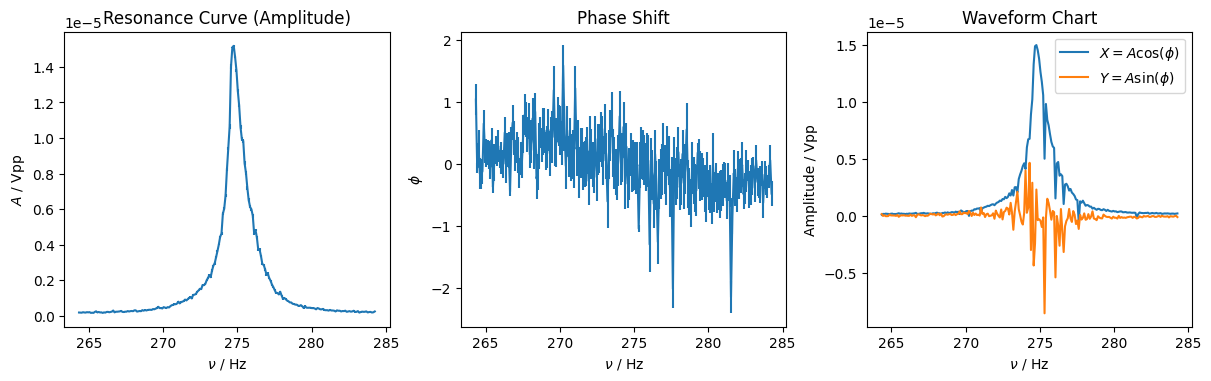

In [7]:
locs = [
    "temp0_data_0708_212553.txt",
    "temp1_data_0708_230411.txt",
    "temp2_data_0709_002229.txt",
    "temp3_data_0709_014047.txt",
    "temp4_data_0709_025905.txt",
    "temp5_data_0709_041723.txt",
    "temp6_data_0709_053541.txt",
    "temp8_data_0709_081217.txt",
    "temp7_data_0709_065359.txt",
    "temp9_data_0709_093035.txt",
]
path = "Data/Night Measurement/Experiment_B/"
locs = [path + loc for loc in locs]

for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)

    fig, axs = plt.subplots(1, 3, figsize=(4*3, 3.7), constrained_layout=True)
    plot_freq_spectrum(fig, axs, data)
    plot_target_freq(axs[0], lowest_harmonic)
    plot_target_freq(axs[1], lowest_harmonic)
    plot_target_freq(axs[2], lowest_harmonic)
    fig.suptitle(f"Analysis Around Resonance at $ f = {lowest_harmonic:.2f}$ Hz")
    plt.show()

In [ ]:
def find_maxima(data):
    (freq, A, A_err, phi, phi_err) = data

    i = np.argmax(A)
    return freq[i], A[i], A_err[i]

In [ ]:
freqs = []
temps = []
for i, loc in enumerate(locs):
    data, metadata = read_exp_file(loc)

    freq, A, A_err = find_maxima(data)
    freqs.append(freq)
    temps.append(metadata["current_temp"])


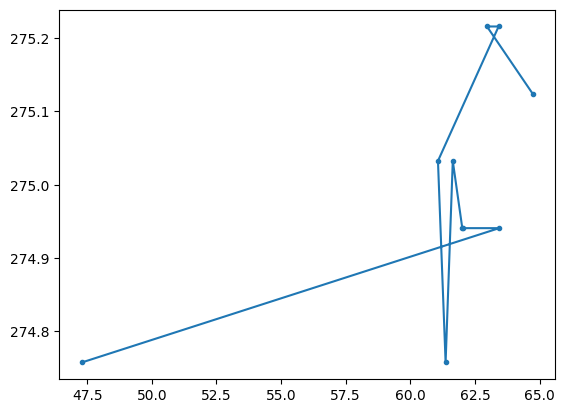

In [ ]:
plt.plot(temps, freqs, marker=".")

In [ ]:
current_temps = []
target_voltage = []
for loc in locs:
    data, metadata = read_exp_file(loc)
    current_temps.append(metadata["current_temp"])
    target_voltage.append(calc_voltage_for_temp(metadata["target_temp"]))
    
    calc_voltage_for_temp(metadata["target_temp"])

plt.plot(target_voltage, current_temps, marker=".")

NameError: name 'calc_voltage_for_temp' is not defined

In [ ]:
from Code.device_managers import illegal_calc_voltage_for_temp, calc_temp_for_voltage



In [ ]:
# fit functions for spectra
# calc chi square and p value
# plot residuals
# güte des resonators

# part b
# fit each spectrum (g.o.f.)
# resonance frequencies against temp plot
# linear regression fit
# slope = temp coeff
# vorzeichen der steigung

